# First Name: Jack
# Last Name: Kelly

# Import Libraries  

In [44]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import statsmodels.formula.api as smf
import statsmodels.api as sm

# Import Data

In [13]:
bottledata = pd.read_csv('Bottle.csv', low_memory=False)
pd.set_option('display.float_format', lambda x:'%f'%x)

# Data management 

In [14]:
sub4 = bottledata.copy()

#grab a specific height for all samples
sub4 = sub4[(sub4['R_Depth'] == 50)]

#grab a specific month (June in this case)
sub4['Month'] = sub4['Depth_ID'].astype(str)
sub4['Month'] = sub4['Month'].apply(lambda x: x[5:7])
sub4['Month'] = pd.to_numeric(sub4['Month'], errors = 'coerce')
sub4 = sub4[(sub4['Month'] == 6)]

#rename oxygen to something that will interact with Python easier
sub4['O2mol'] = sub4['Oxy_µmol/Kg'].copy()

#dropna
sub4 = sub4.dropna(subset = ['Phaeop','STheta', 'R_Depth', 'O2mol', 'Month' ])

#grab only required values
sub4 = sub4[['Phaeop','STheta','R_TEMP', 'O2mol']]

#create centred values in new columns
sub4['Phaeop_c'] = (sub4['Phaeop'] - sub4['Phaeop'].mean())
sub4['STheta_c'] = (sub4['STheta'] - sub4['STheta'].mean())
sub4['R_TEMP_c'] = (sub4['R_TEMP'] - sub4['R_TEMP'].mean())
sub4['O2mol_c'] = (sub4['O2mol'] - sub4['O2mol'].mean())

print(len(sub4))
sub4.head()

179


,Phaeop,STheta,R_TEMP,O2mol,Phaeop_c,STheta_c,R_TEMP_c,O2mol_c
551057,0.350000,25.289000,12.710000,201.240000,0.031296,0.201403,-1.017207,-18.898180
551076,0.330000,25.373000,12.530000,186.850400,0.011296,0.285403,-1.197207,-33.287780
551106,0.220000,25.152000,12.920000,225.662900,-0.098704,0.064403,-0.807207,5.524720
551136,0.180000,25.187000,12.810000,222.170200,-0.138704,0.099403,-0.917207,2.032020
551160,0.140000,25.292000,12.330000,212.129000,-0.178704,0.204403,-1.397207,-8.009180


# Correlation between each explantory variable and response variable

In [15]:
#relationship between Phaeopigment and Density
test1 = smf.ols('Phaeop ~ STheta', data=sub4).fit()
print(test1.summary())

                            OLS Regression Results                            
Dep. Variable:                 Phaeop   R-squared:                       0.389
Model:                            OLS   Adj. R-squared:                  0.386
Method:                 Least Squares   F-statistic:                     112.8
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.07e-20
Time:                        10:34:47   Log-Likelihood:                -2.9210
No. Observations:                 179   AIC:                             9.842
Df Residuals:                     177   BIC:                             16.22
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     -9.3240      0.908    -10.267      0.0

In [26]:
#relationship between Phaeopigment and Temperature
test2 = smf.ols('Phaeop ~ R_TEMP', data=sub4).fit()
print(test2.summary())

                            OLS Regression Results                            
Dep. Variable:                 Phaeop   R-squared:                       0.369
Model:                            OLS   Adj. R-squared:                  0.366
Method:                 Least Squares   F-statistic:                     103.7
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.83e-19
Time:                        11:18:06   Log-Likelihood:                -5.7686
No. Observations:                 179   AIC:                             15.54
Df Residuals:                     177   BIC:                             21.91
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.4990      0.117     12.767      0.0

In [17]:
#relationship between Phaeopigment and Oxygen
test3 = smf.ols('Phaeop ~ O2mol', data=sub4).fit()
print(test3.summary())

                            OLS Regression Results                            
Dep. Variable:                 Phaeop   R-squared:                       0.214
Model:                            OLS   Adj. R-squared:                  0.209
Method:                 Least Squares   F-statistic:                     48.06
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           7.43e-11
Time:                        10:34:49   Log-Likelihood:                -25.545
No. Observations:                 179   AIC:                             55.09
Df Residuals:                     177   BIC:                             61.47
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept      1.0415      0.106      9.793      0.0

# Scatter plot between each explantory variable and response variable

Text(0, 0.5, 'Phaeopigment Micrograms/L')

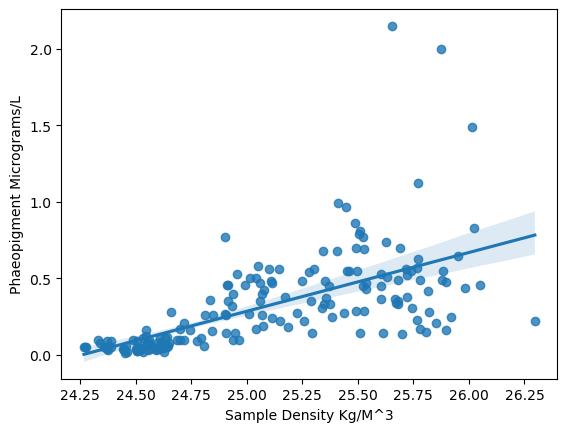

In [22]:
#Scatter between phaeopigment and density
%matplotlib inline
plt.figure()
scat1 = sns.regplot(x="STheta", y="Phaeop", fit_reg=True, data=sub4)
plt.xlabel('Sample Density Kg/M^3')
plt.ylabel('Phaeopigment Micrograms/L')

Text(0, 0.5, 'Phaeopigment Micrograms/L')

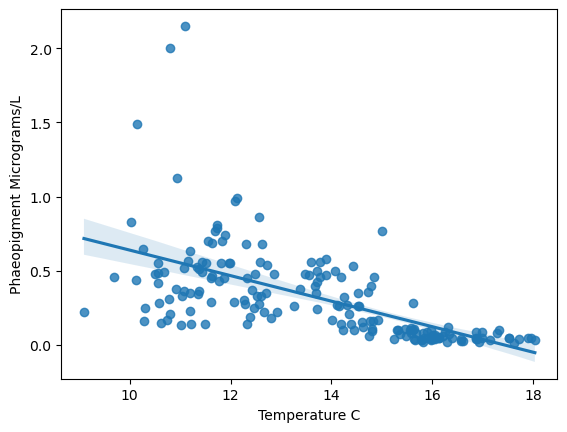

In [29]:
#Scatter between phaeopigment and temperature
%matplotlib inline
plt.figure()
scat1 = sns.regplot(x="R_TEMP", y="Phaeop", fit_reg=True, data=sub4)
plt.xlabel('Temperature C')
plt.ylabel('Phaeopigment Micrograms/L')

Text(0, 0.5, 'Phaeopigment Micrograms/L')

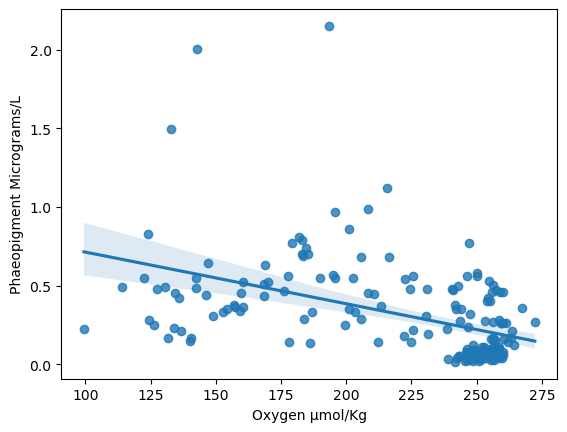

In [23]:
#Scatter between phaeopigment and oxygen
%matplotlib inline
plt.figure()
scat1 = sns.regplot(x="O2mol", y="Phaeop", fit_reg=True, data=sub4)
plt.xlabel('Oxygen µmol/Kg')
plt.ylabel('Phaeopigment Micrograms/L')

# Regression Analysis for each candidate

In [40]:
#model A - Y ~ X1² + X2 + X3
model1reg = smf.ols('Phaeop_c ~ I(STheta_c**2) + R_TEMP_c + O2mol_c', data=sub4).fit()
print(model1reg.summary())

                            OLS Regression Results                            
Dep. Variable:               Phaeop_c   R-squared:                       0.376
Model:                            OLS   Adj. R-squared:                  0.365
Method:                 Least Squares   F-statistic:                     35.11
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           8.16e-18
Time:                        12:10:05   Log-Likelihood:                -4.8752
No. Observations:                 179   AIC:                             17.75
Df Residuals:                     175   BIC:                             30.50
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0101      0.039  

In [41]:
# model B - Y ~ X1 + X2² + X3
model2reg = smf.ols('Phaeop_c ~ STheta_c + I(R_TEMP_c**2) + O2mol_c', data=sub4).fit()
print(model2reg.summary())

                            OLS Regression Results                            
Dep. Variable:               Phaeop_c   R-squared:                       0.419
Model:                            OLS   Adj. R-squared:                  0.409
Method:                 Least Squares   F-statistic:                     42.11
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           1.55e-20
Time:                        12:10:09   Log-Likelihood:                 1.5875
No. Observations:                 179   AIC:                             4.825
Df Residuals:                     175   BIC:                             17.57
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept           -0.0102      0.036  

In [42]:
# model C - Y ~ X1 + X2 + X3²
model3reg = smf.ols('Phaeop_c ~ STheta_c + R_TEMP_c + I(O2mol_c**2)', data=sub4).fit()
print(model3reg.summary())

                            OLS Regression Results                            
Dep. Variable:               Phaeop_c   R-squared:                       0.454
Model:                            OLS   Adj. R-squared:                  0.445
Method:                 Least Squares   F-statistic:                     48.53
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           7.11e-23
Time:                        12:10:13   Log-Likelihood:                 7.1365
No. Observations:                 179   AIC:                            -6.273
Df Residuals:                     175   BIC:                             6.477
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
Intercept           0.0814      0.025     

In [43]:
# model D - Y ~ X1 + X22 + X33
model4reg = smf.ols('Phaeop_c ~ STheta_c + I(R_TEMP_c**2) + I(O2mol_c**3)', data=sub4).fit()
print(model4reg.summary())

                            OLS Regression Results                            
Dep. Variable:               Phaeop_c   R-squared:                       0.442
Model:                            OLS   Adj. R-squared:                  0.433
Method:                 Least Squares   F-statistic:                     46.27
Date:                Wed, 15 Apr 2026   Prob (F-statistic):           4.56e-22
Time:                        12:10:22   Log-Likelihood:                 5.2218
No. Observations:                 179   AIC:                            -2.444
Df Residuals:                     175   BIC:                             10.31
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                       coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------
Intercept            0.0191      0.027  

# Q-Q plot for each candidate 

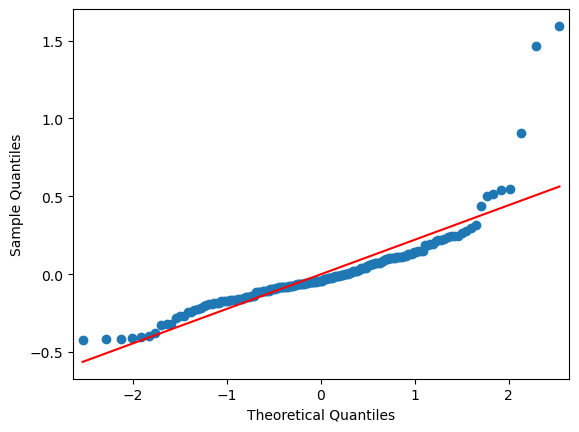

In [45]:
#model A
fig1 = sm.qqplot(model1reg.resid, line='r')

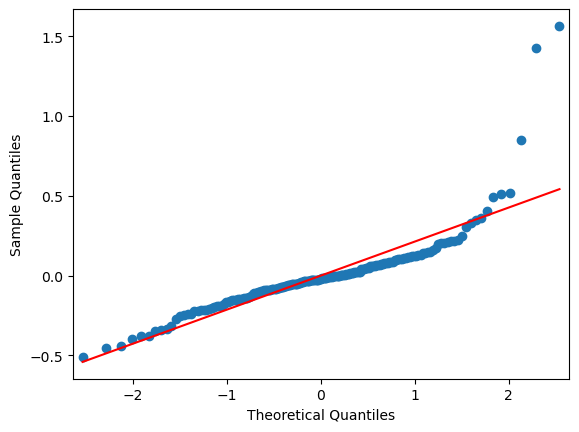

In [46]:
#model B
fig2 = sm.qqplot(model2reg.resid, line='r')

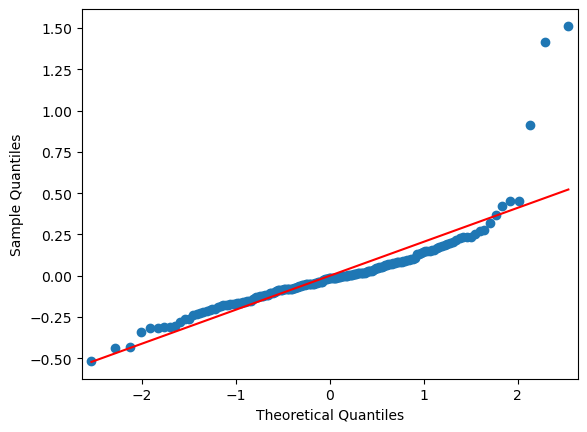

In [47]:
#model C
fig3 = sm.qqplot(model3reg.resid, line='r')

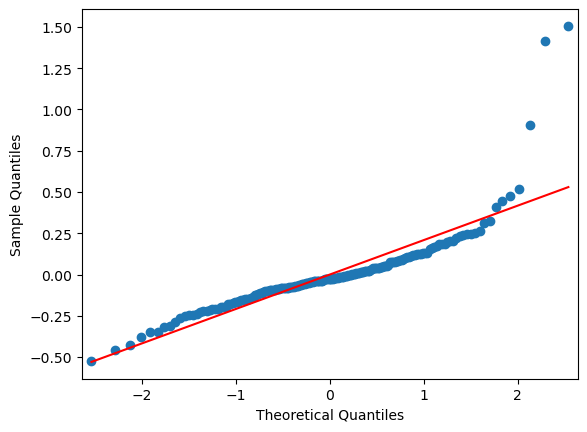

In [48]:
#model D
fig4 = sm.qqplot(model4reg.resid, line='r')

# standardized residual plots

3.35195530726257
1.675977653631285


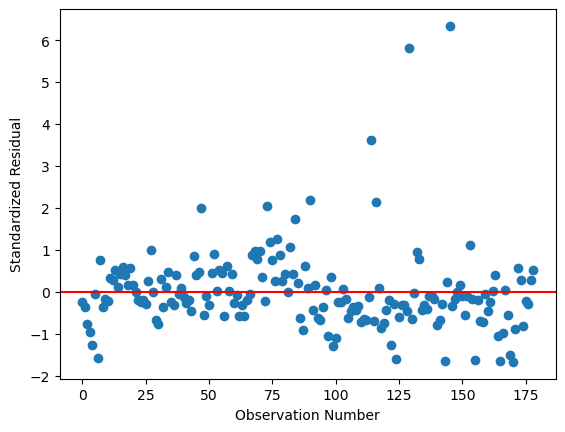

In [53]:
# model A plot of residuals
stdres1 = pd.DataFrame(model1reg.resid_pearson)
plt.figure()
plt.plot(stdres1, 'o', ls='None')
l = plt.axhline(y=0, color='r')
plt.ylabel('Standardized Residual')
plt.xlabel('Observation Number')

# residual standard deviation(s)
percentage_over2sd1 = (np.count_nonzero( stdres1[0] > 2) + np.count_nonzero( stdres1[0] < -2))/len(stdres1)*100
print (percentage_over2sd1)
percentage_over2_5sd1 = (np.count_nonzero( stdres1[0] > 2.5) + np.count_nonzero( stdres1[0] < -2.5))/len(stdres1)*100
print (percentage_over2_5sd1)

3.910614525139665
1.675977653631285


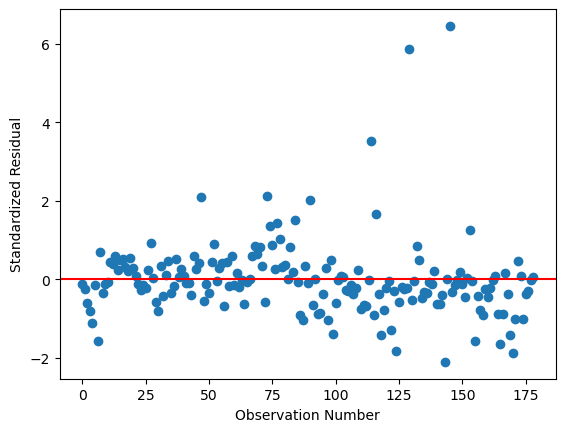

In [54]:
# model B plot of residuals
stdres2 = pd.DataFrame(model2reg.resid_pearson)
plt.figure()
plt.plot(stdres2, 'o', ls='None')
l = plt.axhline(y=0, color='r')
plt.ylabel('Standardized Residual')
plt.xlabel('Observation Number')

# residual standard deviation(s)
percentage_over2sd2 = (np.count_nonzero( stdres2[0] > 2) + np.count_nonzero( stdres2[0] < -2))/len(stdres2)*100
print (percentage_over2sd2)
percentage_over2_5sd2 = (np.count_nonzero( stdres2[0] > 2.5) + np.count_nonzero( stdres2[0] < -2.5))/len(stdres2)*100
print (percentage_over2_5sd2)

2.2346368715083798
1.675977653631285


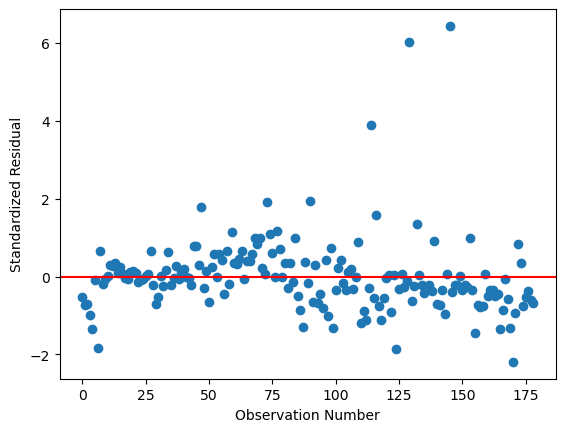

In [55]:
# model C plot of residuals
stdres3 = pd.DataFrame(model3reg.resid_pearson)
plt.figure()
plt.plot(stdres3, 'o', ls='None')
l = plt.axhline(y=0, color='r')
plt.ylabel('Standardized Residual')
plt.xlabel('Observation Number')

# residual standard deviation(s)
percentage_over2sd3 = (np.count_nonzero( stdres3[0] > 2) + np.count_nonzero( stdres3[0] < -2))/len(stdres3)*100
print (percentage_over2sd3)
percentage_over2_5sd3 = (np.count_nonzero( stdres3[0] > 2.5) + np.count_nonzero( stdres3[0] < -2.5))/len(stdres3)*100
print (percentage_over2_5sd3)

3.35195530726257
1.675977653631285


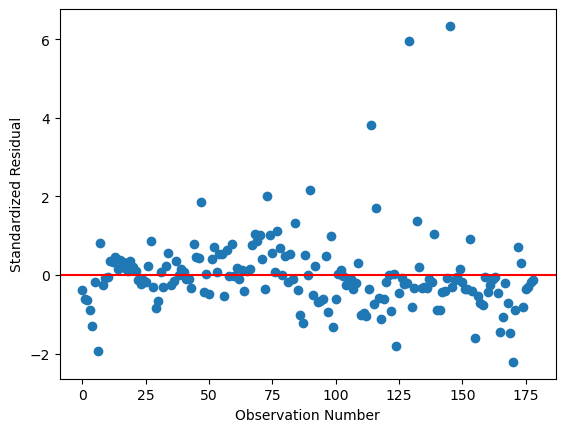

In [56]:
# model D plot of residuals
stdres4 = pd.DataFrame(model4reg.resid_pearson)
plt.figure()
plt.plot(stdres4, 'o', ls='None')
l = plt.axhline(y=0, color='r')
plt.ylabel('Standardized Residual')
plt.xlabel('Observation Number')

# residual standard deviation(s)
percentage_over2sd4 = (np.count_nonzero( stdres4[0] > 2) + np.count_nonzero( stdres4[0] < -2))/len(stdres4)*100
print (percentage_over2sd4)
percentage_over2_5sd4 = (np.count_nonzero( stdres4[0] > 2.5) + np.count_nonzero( stdres4[0] < -2.5))/len(stdres4)*100
print (percentage_over2_5sd4)